# 1) Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2) Import libraries

In [2]:
pip install tensorly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 51.1 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import os
from skimage.io import imread_collection
from matplotlib.image import imread
from matplotlib import pyplot
from PIL import Image
import os, os.path
from skimage import io
import tensorly as tl
from tensorly.tenalg import mode_dot
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sn

# 3) Read data & Show multiple images

hole directory

In [4]:
file_count = sum(len(files) for _, _, files in os.walk('/content/drive/MyDrive/ML/computational data mining/تمرین هشتم/'))
print(file_count)

172


train data

In [5]:
file_count = sum(len(files) for _, _, files in os.walk('/content/drive/MyDrive/ML/computational data mining/تمرین هشتم/yalefaces/train'))
print(file_count)

135


test data

In [6]:
file_count = sum(len(files) for _, _, files in os.walk('/content/drive/MyDrive/ML/computational data mining/تمرین هشتم/yalefaces/test'))
print(file_count)

30


Read train & test data

In [7]:
#creating a collection with the available images
train = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین هشتم/yalefaces/train')
test = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین هشتم/yalefaces/test')

In [8]:
print(type(train))
print(type(test))

<class 'skimage.io.collection.ImageCollection'>
<class 'skimage.io.collection.ImageCollection'>


Show train data

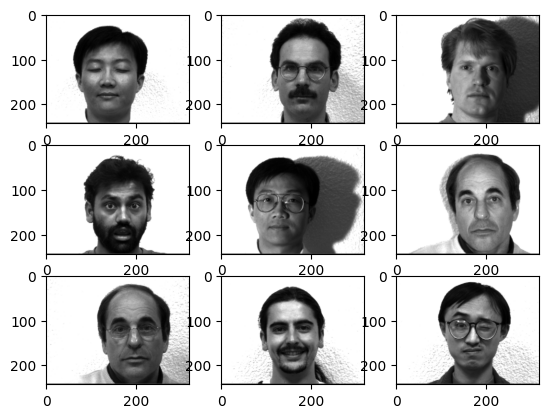

In [9]:
folder = '/content/drive/MyDrive/ML/computational data mining/تمرین هشتم/yalefaces/train'    #folder where your photos are store

data_paths = [i for i in (os.path.join(folder, f) for f in os.listdir(folder)) if os.path.isfile(i)]

# plot first few images
for i in range(9):
    # define subplot
    pyplot.subplot(330 + 1 + i)

    x= data_paths[i]
    # load image pixels
    image = imread(x)
    # plot raw pixel data
    pyplot.imshow(image, cmap='gray')


Show test data

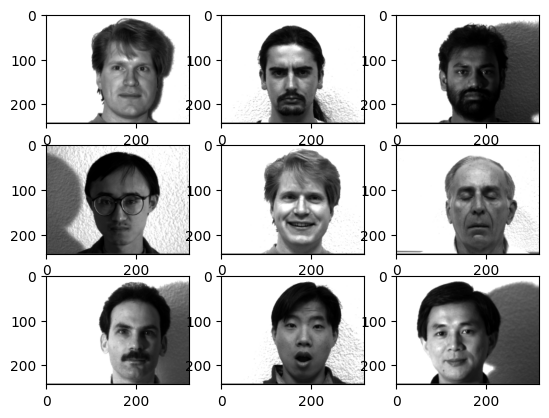

In [10]:
folder = '/content/drive/MyDrive/ML/computational data mining/تمرین هشتم/yalefaces/test'    #folder where your photos are store

data_paths = [i for i in (os.path.join(folder, f) for f in os.listdir(folder)) if os.path.isfile(i)]

# plot first few images
for i in range(9):
    # define subplot
    pyplot.subplot(330 + 1 + i)

    x= data_paths[i]
    # load image pixels
    image = imread(x)
    # plot raw pixel data
    pyplot.imshow(image, cmap='gray')


# 4) Labling of train & test data

## lable for train data

In [11]:
train_img_names = []
path = '/content/drive/MyDrive/ML/computational data mining/تمرین هشتم/yalefaces/train'

for f in os.listdir(path):
    ext = os.path.splitext(f)[1]
    train_img_names.append(f)

print(len(train_img_names))
print(train_img_names[0: 3])

135
['subject14.sleepy.gif', 'subject02.glasses.gif', 'subject01.leftlight.gif']


In [12]:
train_labels = []
for img_title in train_img_names:
  digit = ''.join([n for n in img_title if n.isdigit()])
  train_labels.append(int(digit))
print(len(train_labels))
print(train_labels[0:3])


135
[14, 2, 1]


## lable for test data

In [13]:
test_img_names = []
path = '/content/drive/MyDrive/ML/computational data mining/تمرین هشتم/yalefaces/test'

for f in os.listdir(path):
    ext = os.path.splitext(f)[1]
    test_img_names.append(f)

print(len(test_img_names))
print(test_img_names[0: 3])

30
['subject01.gif', 'subject09.sad.gif', 'subject07.leftlight.gif']


In [14]:
test_labels = []
for img_title in test_img_names:
  digit = ''.join([n for n in img_title if n.isdigit()])
  test_labels.append(int(digit))
print(len(test_labels))
print(test_labels[0:3])

30
[1, 9, 7]


# 5) Make tensor A

## make tesor A

In [15]:
image = imread(data_paths[0])
print('shape of first image: ', image.shape)
print('dtype of first image: ',image.dtype)
print('type of first image: ',type(image))


shape of first image:  (243, 320)
dtype of first image:  uint8
type of first image:  <class 'numpy.ndarray'>


In [16]:
# flatten all images in train data
folder = '/content/drive/MyDrive/ML/computational data mining/تمرین هشتم/yalefaces/train'    #folder where your photos are store

data_paths = [i for i in (os.path.join(folder, f) for f in os.listdir(folder)) if os.path.isfile(i)]

flatten_images = []
for i in range(len(data_paths)):

    x= data_paths[i]
    # load image pixels
    image = imread(x)
    # flatten image
    image = image.flatten()

    flatten_images.append(image)

print(len(flatten_images))
print(flatten_images[0].shape)



135
(77760,)


In [17]:
train_images_matrix = np.stack(flatten_images)
print(train_images_matrix.shape)

(135, 77760)


In [18]:
new_train_images_matrix = []
train_labels_array = np.array(train_labels)

# subject 1 ---> 15
for i in range(1, 16):
  mask = (train_labels_array == i)
  new_train_images_matrix.append(train_images_matrix[mask, :])

print(len(new_train_images_matrix))
print(new_train_images_matrix[0].shape)

15
(9, 77760)


In [19]:
train_images_matrix = np.stack(new_train_images_matrix)
print(train_images_matrix.shape)

(15, 9, 77760)


In [20]:
A = np.transpose(train_images_matrix, (2, 1, 0))
print(A[0].shape)
print(A.shape)

(9, 15)
(77760, 9, 15)


# 6) Calculate HOSVD

## HOSVD algorithm

In [21]:
def multiplication(S, G, mode):

    descriptor = list(S.shape)
    descriptor[mode] = G.shape[0]
    pom = tl.unfold(S, mode)

    return (tl.fold( G @ pom, mode, descriptor))

In [22]:
def HOSVD(A):

    U1, _, _ = np.linalg.svd(tl.unfold(A, 0), full_matrices=False)
    U2, _, _ = np.linalg.svd(tl.unfold(A, 1), full_matrices=False)
    U3, _, _ = np.linalg.svd(tl.unfold(A, 2), full_matrices=False)

    S = tl.tenalg.multi_mode_dot(A, [np.transpose(U1),np.transpose(U2),np.transpose(U3)], modes = [0,1,2], transpose=False)

    return(S, U1, U2, U3)

hosvd_result = HOSVD(A)
S = hosvd_result[0]
U1 = hosvd_result[1]
U2 = hosvd_result[2]
U3 = hosvd_result[3]

print('shape of S:', S.shape)
print('shape of U1:', U1.shape)
print('shape of U2:', U2.shape)
print('shape of U3:', U3.shape)

shape of S: (135, 9, 15)
shape of U1: (77760, 135)
shape of U2: (9, 9)
shape of U3: (15, 15)


## matrix B

In [23]:
F = U1
G = U2
H = U3

B = multiplication(S, G, 1)
print(B.shape)

(135, 9, 15)


## Be - B_list

In [24]:
B0 = B[:, 0, :]
print(B0.shape)

(135, 15)


In [25]:
B_list = []
for i in range(9):
  B_list.append(B[:, i, :])
  print(B_list[i].shape)


(135, 15)
(135, 15)
(135, 15)
(135, 15)
(135, 15)
(135, 15)
(135, 15)
(135, 15)
(135, 15)


## QR Decomposition

In [26]:
Q_list = []
R_list = []
for B in B_list:
  Q, R = np.linalg.qr(B)
  Q_list.append(Q)
  R_list.append(R)

print(len(Q_list))
print(len(R_list))
print(Q_list[0].shape)
print(R_list[0].shape)


9
9
(135, 15)
(15, 15)


# 7) predict label for test data

flatten images of test data

In [27]:
folder = '/content/drive/MyDrive/ML/computational data mining/تمرین هشتم/yalefaces/test'    #folder where your photos are store

data_paths = [i for i in (os.path.join(folder, f) for f in os.listdir(folder)) if os.path.isfile(i)]

flatten_test_list =[]

for i in range(len(data_paths)):
    x= data_paths[i]
    # load image pixels
    image = imread(x)

    flatten_test_list.append(image.flatten())

print(len(flatten_test_list))
print(flatten_test_list[0].shape)

30
(77760,)


In [28]:
z_hat_list = []

for img in flatten_test_list:
  z_hat_list.append(F.transpose().dot(img))

print(len(z_hat_list))
print(z_hat_list[0].shape)

30
(135,)


In [29]:
tol = 0.7

prediction_list = []
alpha_list = []

# 30 test images
for z_hat in z_hat_list:

    min_distances = []
    min_indices = []

    # 9 expression
    for i in range(9):

        b = Q_list[i].T @ z_hat
        alpha = np.linalg.solve(R_list[i], b)
        alpha_list.append(alpha)

        # 15 person
        distance = []

        for j in range(15):
            d = np.linalg.norm(alpha - H[j, :])
            distance.append(d)

        # closest person for expression
        min_distance = min(distance)
        min_index = np.argmin(distance)

        if min_distance < tol:
            min_distances.append(min_distance)
            min_indices.append(min_index)


    if len(min_distances) > 0:
        index = np.argmin(min_distances)
        prediction = min_indices[index]
    else:
        prediction = -1

    prediction_list.append(prediction)

print(len(prediction_list))
print(prediction_list)

30
[np.int64(0), np.int64(8), np.int64(12), np.int64(0), np.int64(0), np.int64(4), np.int64(11), np.int64(3), -1, np.int64(2), np.int64(5), -1, np.int64(6), np.int64(1), np.int64(12), np.int64(4), np.int64(4), np.int64(7), np.int64(10), np.int64(13), np.int64(13), np.int64(11), np.int64(14), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(6), np.int64(12), np.int64(9)]


# 8) Calculate Accuracy & Confusion matrix

### Note on Label Indexing

The initial accuracy was `0.0` because the predicted labels were zero-based (`0–14`), while the true test labels were one-based (`1–15`).

Therefore, the predicted labels were shifted by `+1` to match the true labels before calculating the final accuracy.

```python
predicted_label_corrected = np.array(prediction_list) + 1

In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(test_labels, prediction_list)
print('accuracy score: ', accuracy)

accuracy score:  0.0


In [31]:
print("test_labels:")
print(test_labels)

print("predicted_label:")
print(prediction_list)

test_labels:
[1, 9, 7, 8, 1, 5, 2, 4, 6, 3, 6, 4, 7, 2, 3, 5, 9, 8, 11, 14, 14, 12, 15, 10, 11, 12, 13, 15, 13, 10]
predicted_label:
[np.int64(0), np.int64(8), np.int64(12), np.int64(0), np.int64(0), np.int64(4), np.int64(11), np.int64(3), -1, np.int64(2), np.int64(5), -1, np.int64(6), np.int64(1), np.int64(12), np.int64(4), np.int64(4), np.int64(7), np.int64(10), np.int64(13), np.int64(13), np.int64(11), np.int64(14), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(6), np.int64(12), np.int64(9)]


### Final Accuracy

After correcting the label indexing by shifting the predicted labels by `+1`, the final accuracy was calculated.

The model correctly classified **22 out of 30 test images**.

$$
Accuracy = \frac{22}{30} \approx 0.7333
$$

Therefore, the final accuracy is:

**73.33%**

In [32]:
predicted_label_corrected = np.array(prediction_list) + 1

accuracy = accuracy_score(test_labels, predicted_label_corrected)
print('accuracy score: ', accuracy)


accuracy score:  0.7333333333333333


In [33]:
from sklearn.metrics import classification_report

class_report = classification_report(
    test_labels,
    predicted_label_corrected,
    labels=range(1, 16)
)

print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           1       0.67      1.00      0.80         2
           2       1.00      0.50      0.67         2
           3       1.00      0.50      0.67         2
           4       1.00      0.50      0.67         2
           5       0.67      1.00      0.80         2
           6       1.00      0.50      0.67         2
           7       0.50      0.50      0.50         2
           8       1.00      0.50      0.67         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       0.67      1.00      0.80         2
          13       0.50      1.00      0.67         2
          14       1.00      1.00      1.00         2
          15       1.00      0.50      0.67         2

   micro avg       0.79      0.73      0.76        30
   macro avg       0.87      0.73      0.75        30
wei

In [34]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(
    test_labels,
    predicted_label_corrected,
    labels=range(1, 16)
)

print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[2 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 2 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 2 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 2 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 2 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 2 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 2 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 1]]


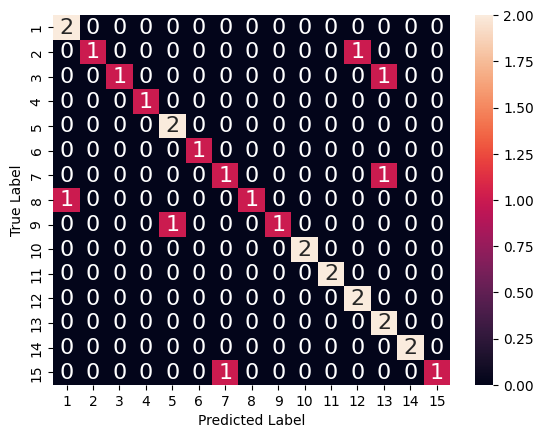

In [35]:
sn.heatmap(
    conf_matrix,
    annot=True,
    xticklabels=range(1, 16),
    yticklabels=range(1, 16),
    annot_kws={"size": 16}
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()